In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 
from matplotlib.patches import FancyArrowPatch
plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'

fsize = 9
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": fsize,
    "axes.titlesize": fsize,
    "axes.labelsize": fsize,
    "xtick.labelsize": fsize,
    "ytick.labelsize": fsize,
    "legend.fontsize": fsize,
})


In [3]:
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.mplot3d.axes3d import Axes3D


def _cone_tris(tip, base_center, radius, n=24):
    tip = np.asarray(tip, float)
    base_center = np.asarray(base_center, float)
    axis = tip - base_center
    L = np.linalg.norm(axis)
    if L == 0:
        return []
    d = axis / L
    ref = np.array([0.0, 0.0, 1.0]) if abs(d[2]) < 0.9 else np.array([1.0, 0.0, 0.0])
    u = np.cross(d, ref); u /= np.linalg.norm(u)
    w = np.cross(d, u)

    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    ring = (base_center[None, :]
            + radius * np.cos(theta)[:, None] * u[None, :]
            + radius * np.sin(theta)[:, None] * w[None, :])

    tris = []
    for i in range(n):
        tris.append([tip, ring[i], ring[(i + 1) % n]])
    for i in range(n):
        tris.append([base_center, ring[(i + 1) % n], ring[i]])
    return tris


def quiver_cone(ax,
                X, Y, Z, U, V, W,
                length=1.0,
                normalize=False,
                color="k",
                linewidth=1.0,
                headlength=0.1,
                headwidth=0.05,
                arrow_length_ratio=None,   # accepted for compat, ignored
                pivot="tail",
                length_includes_head=True,
                n_cone=24,
                **kwargs):
    """
    Quiver-like 3D arrow with a real cone head.

    (X,Y,Z) : start point
    (U,V,W) : VECTOR — arrow goes from (X,Y,Z) to (X+U, Y+V, Z+W)
    """
    X = np.atleast_1d(np.asarray(X, float))
    Y = np.atleast_1d(np.asarray(Y, float))
    Z = np.atleast_1d(np.asarray(Z, float))
    U = np.atleast_1d(np.asarray(U, float))
    V = np.atleast_1d(np.asarray(V, float))
    W = np.atleast_1d(np.asarray(W, float))

    starts = np.column_stack([X, Y, Z])
    vecs   = np.column_stack([U, V, W])   # <-- VECTOR, not endpoint

    if normalize:
        norms = np.linalg.norm(vecs, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        vecs = vecs / norms * length
    else:
        vecs = vecs * length

    azim = np.deg2rad(ax.azim)
    elev = np.deg2rad(ax.elev)
    cam = np.array([np.cos(elev) * np.cos(azim),
                    np.cos(elev) * np.sin(azim),
                    np.sin(elev)])

    n = len(starts)
    depths = np.empty(n)
    for i in range(n):
        P0 = starts[i]
        V_ = vecs[i]
        if   pivot == "tail":   mid = P0 + 0.5 * V_
        elif pivot == "middle": mid = P0
        elif pivot == "tip":    mid = P0 - 0.5 * V_
        else: raise ValueError("pivot must be 'tail', 'middle', or 'tip'")
        depths[i] = np.dot(mid, cam)
    order = np.argsort(depths)   # farthest first

    for i in order:
        P0 = starts[i]
        V_ = vecs[i]
        L = np.linalg.norm(V_)
        if L == 0:
            continue
        d = V_ / L

        if   pivot == "tail":   tail = P0
        elif pivot == "middle": tail = P0 - 0.5 * V_
        elif pivot == "tip":    tail = P0 - V_
        tip_full = tail + V_

        if length_includes_head:
            tip         = tip_full
            base_center = tip_full - headlength * d
            line_end    = base_center
        else:
            base_center = tip_full
            tip         = tip_full + headlength * d
            line_end    = tip_full

        z = 100 + depths[i]

        if headlength < L:
            ax.plot([tail[0], line_end[0]],
                    [tail[1], line_end[1]],
                    [tail[2], line_end[2]],
                    color=color, linewidth=linewidth,
                    solid_capstyle="round",
                    zorder=z)

        tris = _cone_tris(tip, base_center, headwidth, n=n_cone)
        if tris:
            poly = Poly3DCollection(tris,
                                    facecolors=color,
                                    edgecolor=color,
                                    linewidths=0.1,
                                    zorder=z + 0.5,
                                    shade=True)
            ax.add_collection3d(poly)


Axes3D.quiver_cone = quiver_cone

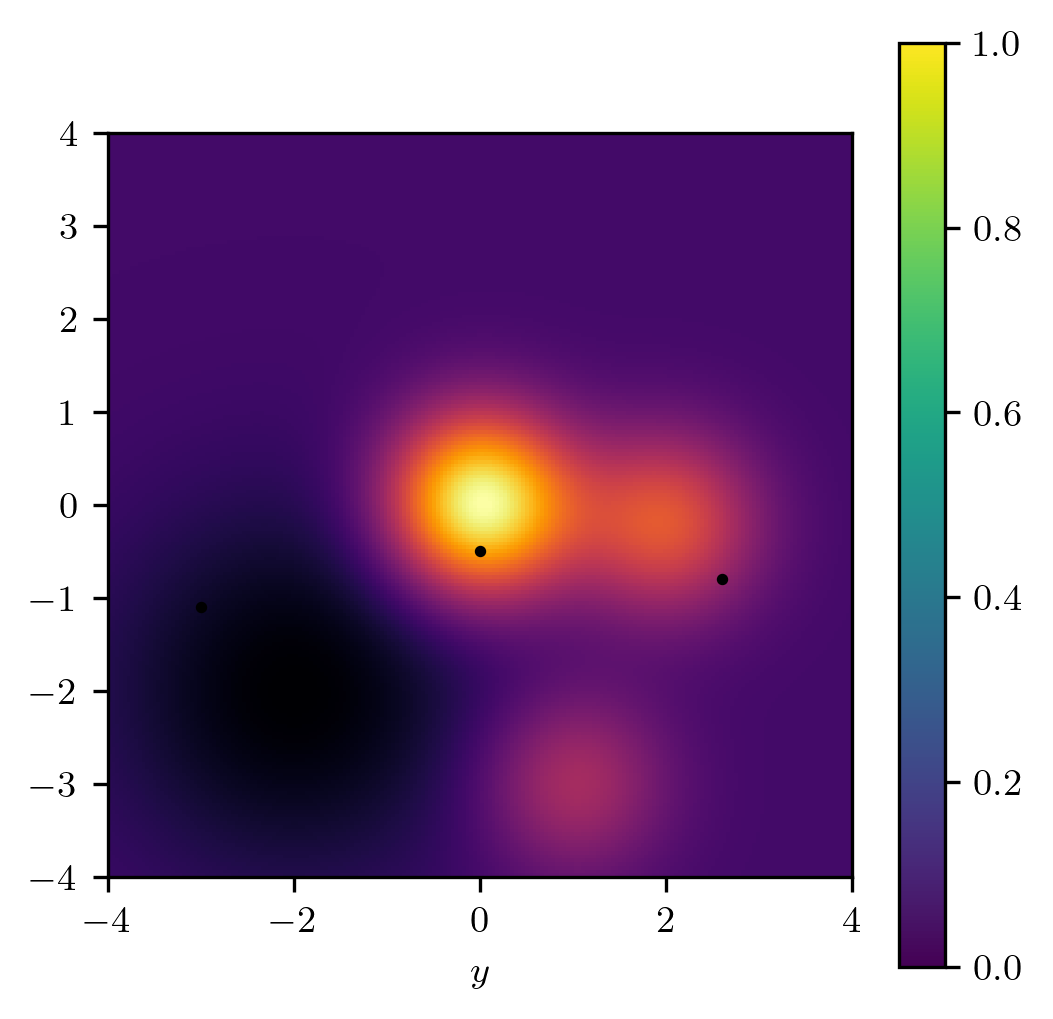

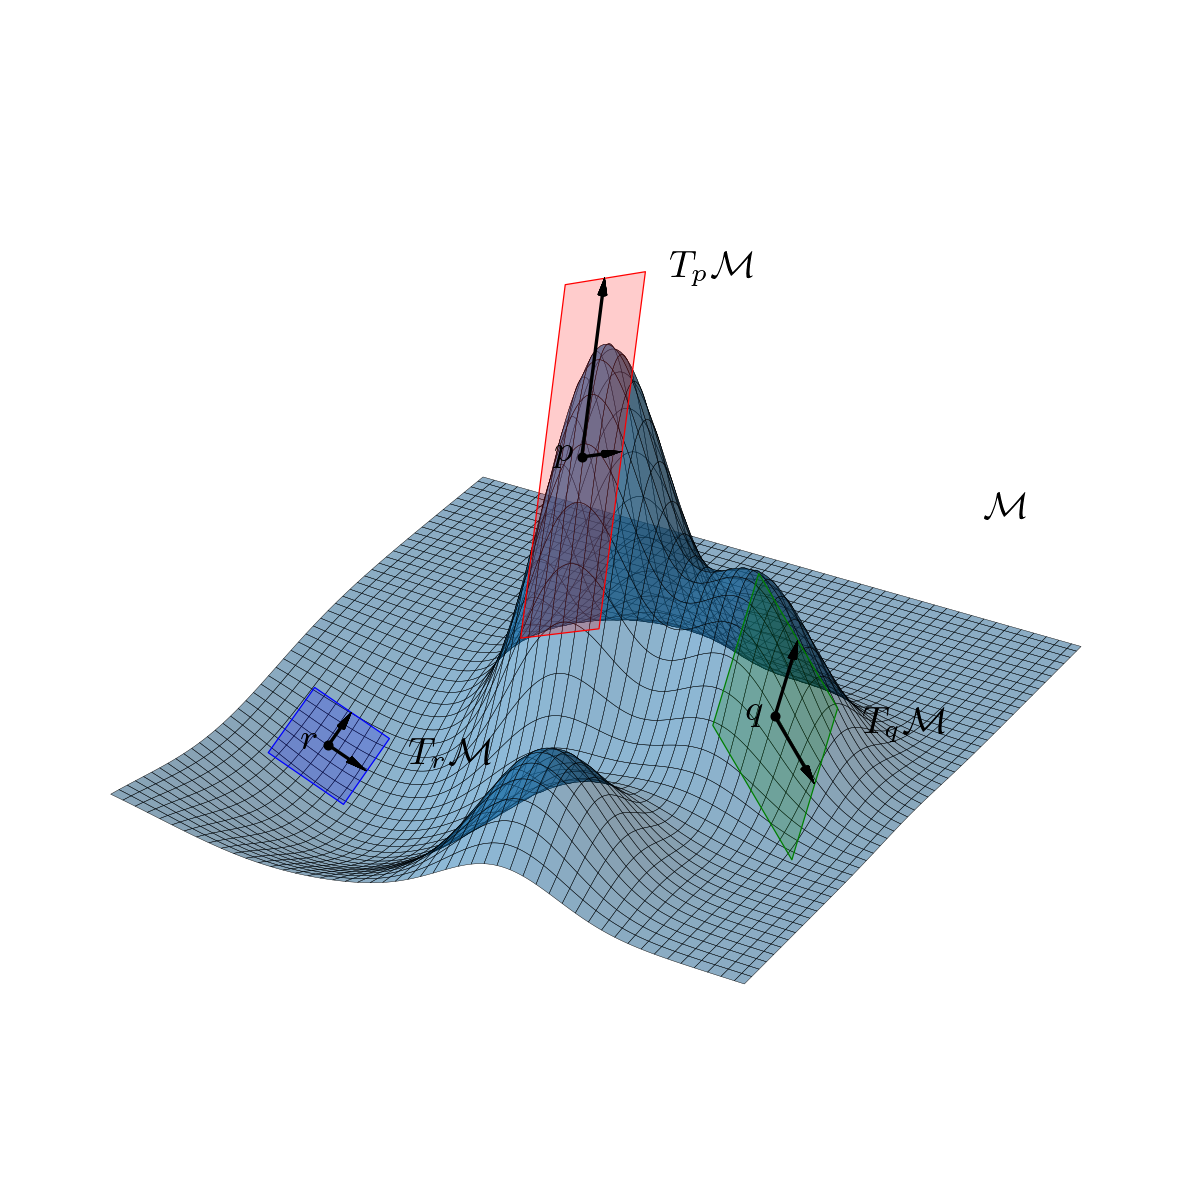

In [20]:
lims = (-4, 4)
x = np.linspace(*lims, 200)
y = np.linspace(*lims, 200)

vx, vy = np.meshgrid(x, y)

def func(x, y):

    def r(x0,y0):
        out = np.sqrt((x-x0)**2 + (y-y0)**2)
        return out 
    
    f = (
        0.8 * np.exp(-r(0,0)**2) + 
        0.4 * np.exp(-r(2,-0.2)**2) + 
        0.25 * np.exp(-r(1,-3)**2) - 
        0.2 * np.exp( (-r(-2,-2)**2)/4)
    )
    return 8 * f

S = func(vx, vy)

p = np.array([0,-0.5])
q = np.array([2.6, -0.8])
r = np.array([-3,-1.1])

plt.figure(figsize=(4,4), dpi  = 300)
plt.imshow(S, extent = [*lims, *lims], cmap = 'inferno', origin = 'lower')
plt.scatter(
    [p[0],q[0],r[0]],
    [p[1],q[1],r[1]],
    color = 'k',
    s = 3,   
    zorder = 3
)
plt.xlabel('$x$')
plt.xlabel('$y$')
plt.colorbar()
plt.show()

fig = plt.figure(figsize=(4, 4), dpi=300)
ax = fig.add_subplot(111, projection="3d", computed_zorder=False)

ax.plot_surface(
    vx, vy, S,
    linewidth=0.1,
    edgecolor="black",
    antialiased=True,
    alpha=0.5,
    zorder = 1
)

color_map = {"p": "r", "q": "g", "r": "b"}
names = ["p", "q", "r"]

for name, point in zip(names, (p, q, r)):
    x0, y0 = point
    z0 = func(x0, y0)
    pt = (x0, y0, z0)

    ax.scatter(*pt, color="black", s=2, depthshade=False, zorder=7)

    h = 1e-6
    dfx = (func(x0 + h, y0) - func(x0 - h, y0)) / (2 * h)
    dfy = (func(x0, y0 + h) - func(x0, y0 - h)) / (2 * h)

    tx = np.array([1.0, 0.0, dfx])
    ty = np.array([0.0, 1.0, dfy])

    scale = 0.5
    ex = scale * tx
    ey = scale * ty

    # --- parallelogram patch ---
    origin = np.array(pt)
    corners = np.array([origin + ex + ey, origin + ex - ey, origin - ex - ey, origin - ex + ey])
    plane = Poly3DCollection(
        [corners],
        facecolors=color_map[name],
        edgecolors=color_map[name],
        linewidths=0.3,
        alpha=0.2,
        zorder=6,
        shade=False,
    )
    ax.add_collection3d(plane)

    # --- cone arrows ---
    ax.quiver_cone(*pt, *ex, color="k", linewidth=0.8,
                   headlength=0.25, headwidth=0.05, zorder=8)
    ax.quiver_cone(*pt, *ey, color="k", linewidth=0.8,
                   headlength=0.25, headwidth=0.05, zorder=8)

    ptlabel = pt + np.array([-0.25,0,0])
    spacelabel = pt + 1.1* scale *(tx + ty) + np.array([0.75,0,0])
    ax.text(*ptlabel, rf'${name}$', ha='center', va='center', zorder = 10)
    ax.text(*spacelabel, rf'$T_{name}\mathcal{{M}}$', ha='center', va='center')

ax.text(*[3,4,2], r'$\mathcal{M}$', ha='center', va='center')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_zlim(-1.6, 6.4)
# ax.set_box_aspect([1, 1, 1])
# ax.set_xlabel("$x$")
# ax.set_ylabel("$y$")
# ax.set_zlabel("$f(x,y)$")
plt.axis('off')
plt.tight_layout()
plt.savefig(r'..\images\tangentspaces.pdf')
plt.show()


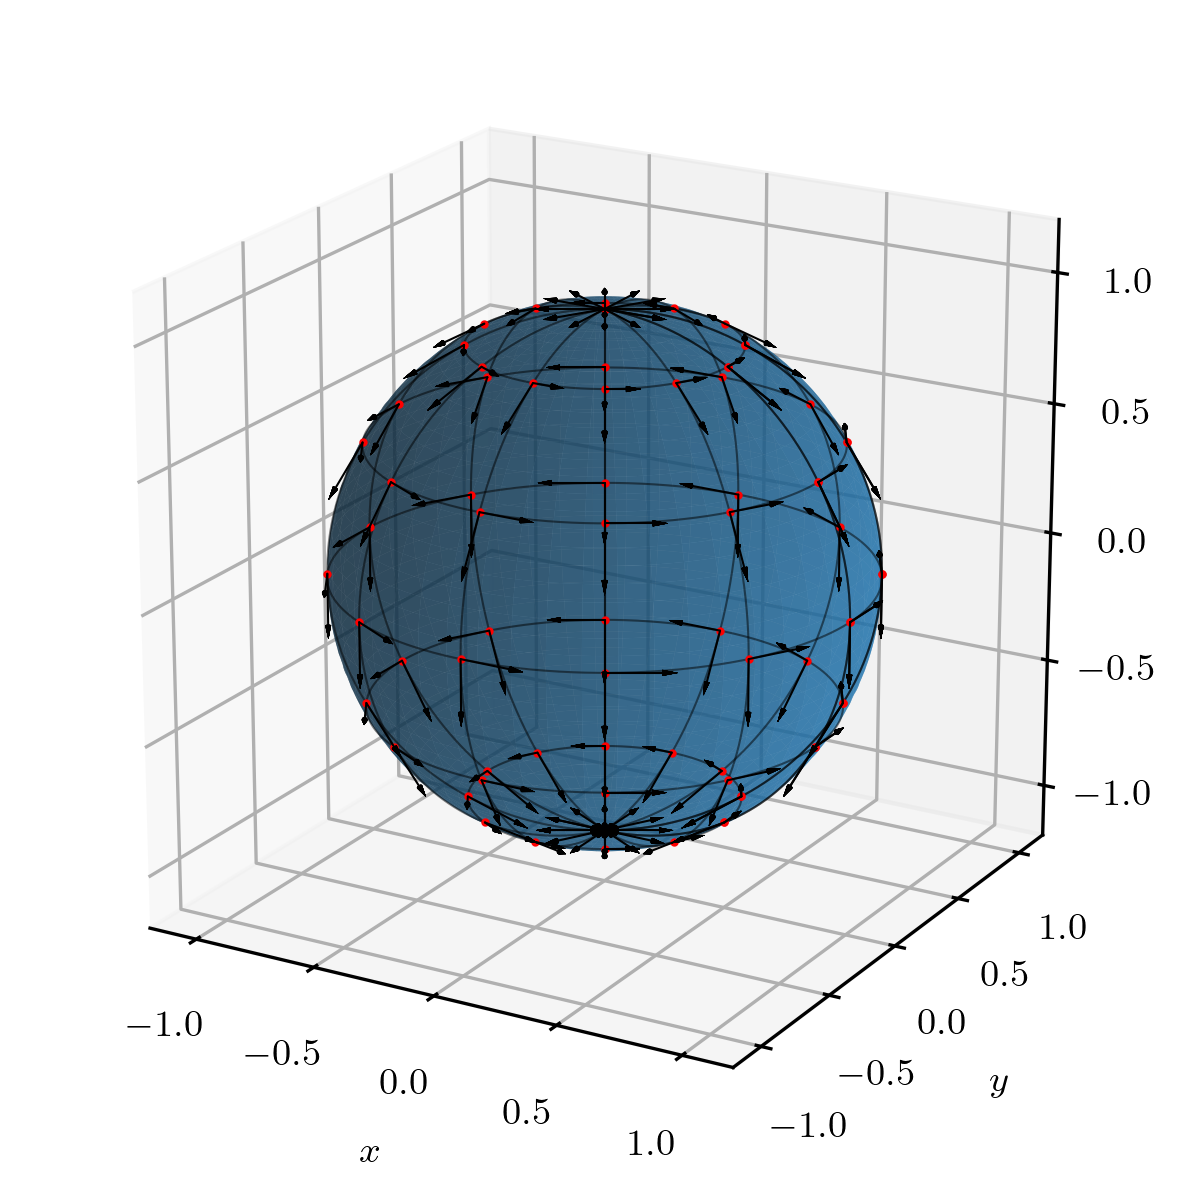

In [28]:
# parameters 
u = np.linspace(0,2*np.pi,1000) # u parameter 
v = np.linspace(0,np.pi,1000) # v parameter 

# radius 
r = 1
# R3 embedding functions x, y, z
def fx(u,v):
    return r * np.cos(u) * np.sin(v)

def fy(u,v):
    return r * np.sin(u) * np.sin(v)

def fz(u,v):
    return r * np.cos(v)

U, V = np.meshgrid(u,v)
R = np.array([
    fx(U,V),
    fy(U,V),
    fz(U,V)
])

fig = plt.figure(figsize=(4, 4), dpi=300)
ax = fig.add_subplot(111, projection='3d', computed_zorder = False)

# manifold embedding
ax.plot_surface(*R, alpha=0.6,
    linewidth=0.1,
    edgecolor=None,
    antialiased=True,
    zorder = 1
                )

# coordinate curves
spaces = np.pi/6

# v coordinate curves
v_0 = np.arange(v.min(), v.max() + spaces, spaces)
for v0 in v_0:
    x0 = fx(u,v0)
    y0 = fy(u,v0)
    z0 = fz(u,v0) * np.ones_like(u)
    ax.plot(x0, y0, z0,'k-',lw=0.5, zorder = 2, alpha = 0.5)

# u coodinate curves
u_0 = np.arange(u.min(), u.max() + spaces, spaces)
for u0 in u_0:
    x0 = fx(u0,v)
    y0 = fy(u0,v)
    z0 = fz(u0,v)
    ax.plot(x0, y0, z0,'k-',lw=0.5, zorder = 2, alpha = 0.5)


# individual basis on a point p
# p = np.pi/6 * np.array([-1,1])
# rp = np.array([fx(*p), fy(*p), fz(*p)])
# ax.scatter(*rp, color = 'r', s = 3, zorder = 5)

# h = 1e-6 
# du_p = np.array([
#     (fx(p[0]+h,p[1]) - fx(p[0]-h,p[1]))/(2*h),
#     (fy(p[0]+h,p[1]) - fy(p[0]-h,p[1]))/(2*h),
#     (fz(p[0]+h,p[1]) - fz(p[0]-h,p[1]))/(2*h)
# ])

# dv_p = np.array([
#     (fx(p[0],p[1]+h) - fx(p[0],p[1]-h))/(2*h),
#     (fy(p[0],p[1]+h) - fy(p[0],p[1]-h))/(2*h),
#     (fz(p[0],p[1]+h) - fz(p[0],p[1]-h))/(2*h)
# ])
   
# ax.quiver_cone(*rp, *du_p, color="k", linewidth=0.8,
#                 headlength=0.25, headwidth=0.05, zorder=4)
# ax.quiver_cone(*rp, *dv_p, color="k", linewidth=0.8,
#                 headlength=0.25, headwidth=0.05, zorder=4)

U0, V0 = np.meshgrid(u_0, v_0)
for u0, v0 in zip(U0.ravel(), V0.ravel()):
    p = np.array([u0, v0])
    rp = np.array([fx(*p), fy(*p), fz(*p)])
    ax.scatter(*rp, color = 'r', s = 1, zorder = 5)

    h = 1e-6 
    du_p = np.array([
        (fx(p[0]+h,p[1]) - fx(p[0]-h,p[1]))/(2*h),
        (fy(p[0]+h,p[1]) - fy(p[0]-h,p[1]))/(2*h),
        (fz(p[0]+h,p[1]) - fz(p[0]-h,p[1]))/(2*h)
    ])

    dv_p = np.array([
        (fx(p[0],p[1]+h) - fx(p[0],p[1]-h))/(2*h),
        (fy(p[0],p[1]+h) - fy(p[0],p[1]-h))/(2*h),
        (fz(p[0],p[1]+h) - fz(p[0],p[1]-h))/(2*h)
    ])
    scale = 1/4

    dv_p *= scale 
    du_p *= scale
    ax.quiver_cone(*rp, *du_p, color="k", linewidth=0.5,
                    headlength=0.05, headwidth=0.01, zorder=4)
    ax.quiver_cone(*rp, *dv_p, color="k", linewidth=0.5,
                    headlength=0.05, headwidth=0.01, zorder=4)
    
lims = (-1.2 * r, 1.2 * r)
ax.set_xlim(*lims)
ax.set_ylim(*lims)
ax.set_zlim(*lims)
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()




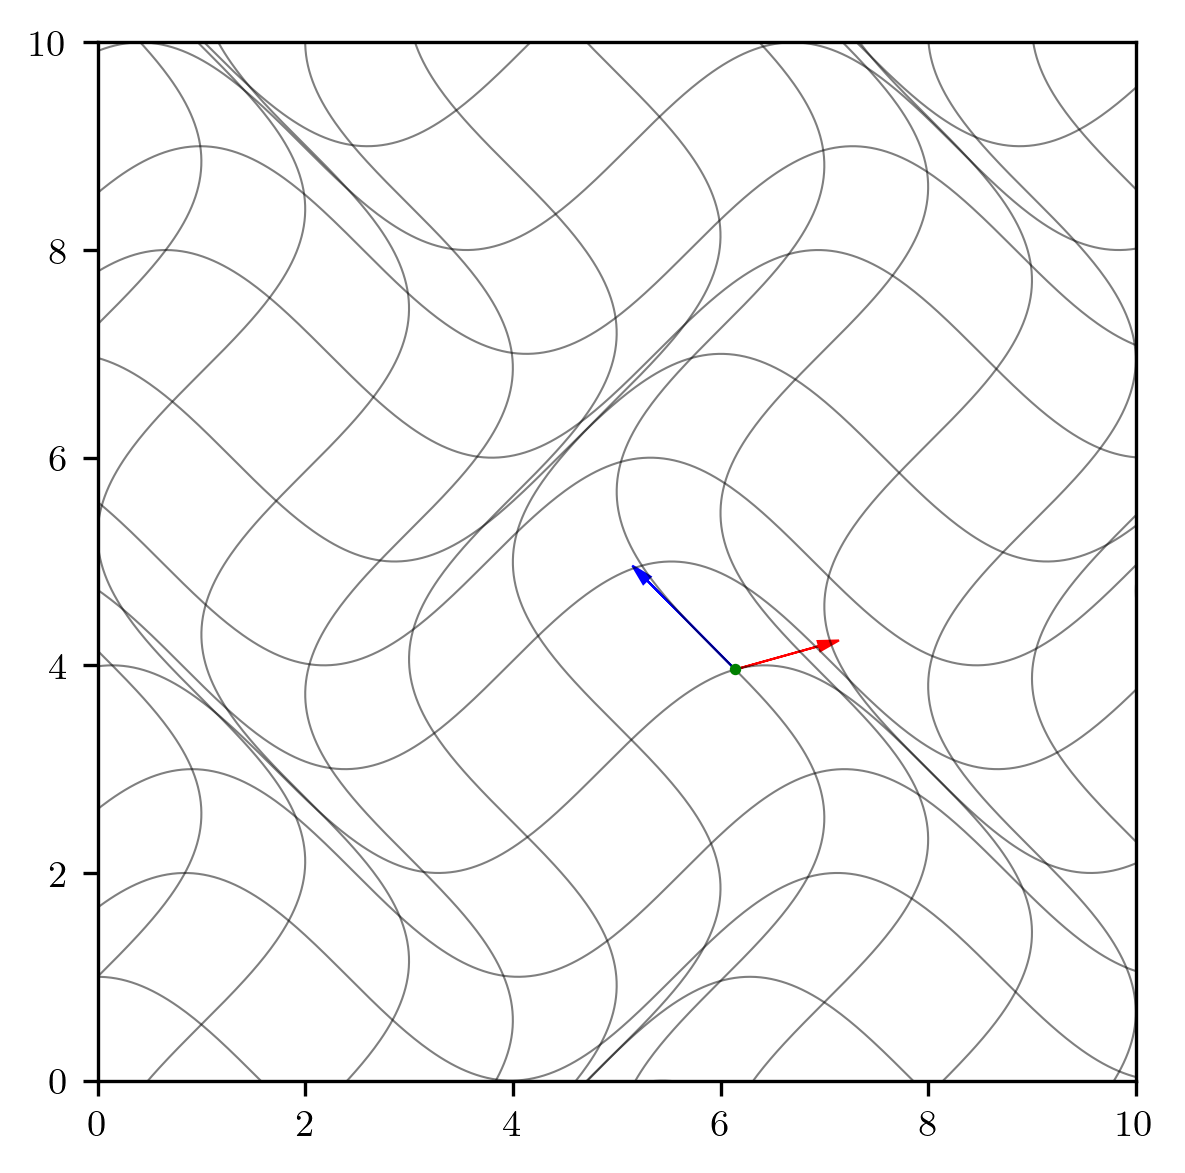

In [51]:
u = np.linspace(-5, 20, 1000)
v = np.linspace(-5, 20, 1000)

def fx(u, v):
    return u + np.sin(v)

def fy(u, v):
    return v + np.cos(u)

plt.figure(figsize=(4, 4), dpi=300)
ax = plt.gca()
ax.set_aspect('equal')

spacing = 1

# u-coordinate curves: fix v = v0, vary u
v_0 = np.arange(v.min(), v.max() + spacing, spacing)
for v0 in v_0:
    x0 = fx(u, v0)
    y0 = fy(u, v0)
    ax.plot(x0, y0, 'k-', lw=0.5, alpha=0.5)

# v-coordinate curves: fix u = u0, vary v
u_0 = np.arange(u.min(), u.max() + spacing, spacing)
for u0 in u_0:
    x0 = fx(u0, v)
    y0 = fy(u0, v)
    ax.plot(x0, y0, 'k-', lw=0.5, alpha=0.5)

p = np.array([6,3])
rp = np.array([fx(*p), fy(*p)])

plt.scatter(*rp, color = 'g', s = 3, zorder = 3)

h = 1e-6
du_p = np.array([
    (fx(p[0]+h,p[1]) - fx(p[0]-h,p[1]))/(2*h),
    (fy(p[0]+h,p[1]) - fy(p[0]-h,p[1]))/(2*h),
])
dv_p = np.array([
    (fx(p[0],p[1]+h) - fx(p[0],p[1]-h))/(2*h),
    (fy(p[0],p[1]+h) - fy(p[0],p[1]-h))/(2*h),
])

plt.arrow(*rp, *du_p, color = 'r', lw = 0.5, length_includes_head = True, head_length = 1/5, head_width = 0.5/5, zorder = 1)
plt.arrow(*rp, *dv_p, color = 'b', lw = 0.5, length_includes_head = True, head_length = 1/5, head_width = 0.5/5, zorder = 1)

plt.xlim(0,10)
plt.ylim(0,10)
plt.tight_layout()
plt.show()

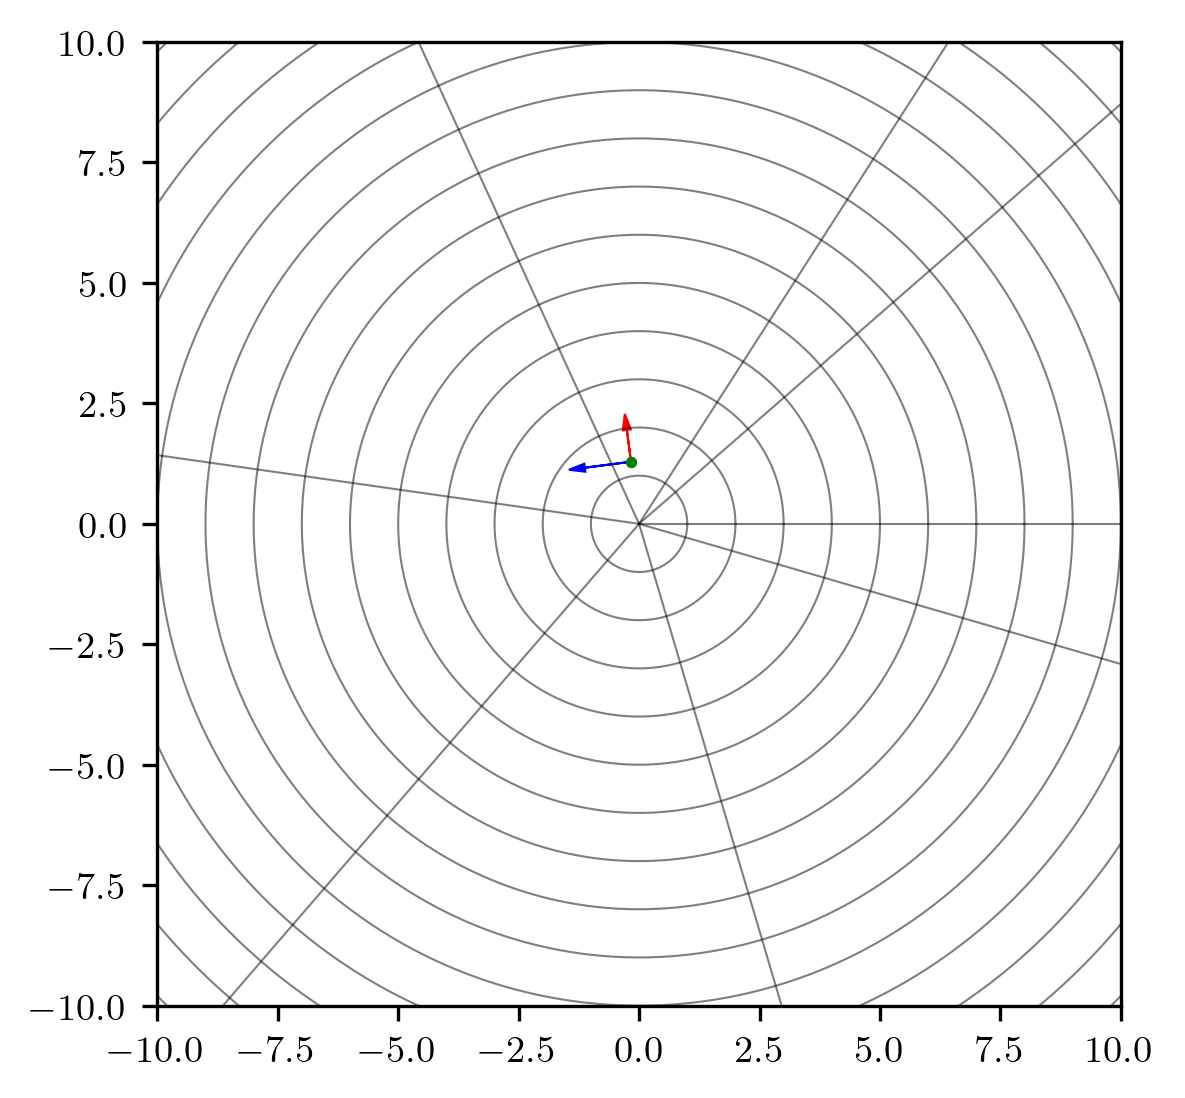

In [ ]:
u = np.linspace(0, 20, 1000)
v = np.linspace(0, 2*np.pi, 1000)

def fx(u, v):
    return u * np.cos(v)

def fy(u, v):
    return u * np.sin(v)

plt.figure(figsize=(4, 4), dpi=300)
ax = plt.gca()
ax.set_aspect('equal')

spacing = 1

# u-coordinate curves: fix v = v0, vary u
v_0 = np.arange(v.min(), v.max() + spacing, spacing)
for v0 in v_0:
    x0 = fx(u, v0)
    y0 = fy(u, v0)
    ax.plot(x0, y0, 'k-', lw=0.5, alpha=0.5)

# v-coordinate curves: fix u = u0, vary v
u_0 = np.arange(u.min(), u.max() + spacing, spacing)
for u0 in u_0:
    x0 = fx(u0, v)
    y0 = fy(u0, v)
    ax.plot(x0, y0, 'k-', lw=0.5, alpha=0.5)

p = np.array([1.3,1.7])
rp = np.array([fx(*p), fy(*p)])

plt.scatter(*rp, color = 'g', s = 3, zorder = 3)

h = 1e-6
du_p = np.array([
    (fx(p[0]+h,p[1]) - fx(p[0]-h,p[1]))/(2*h), 
    (fy(p[0]+h,p[1]) - fy(p[0]-h,p[1]))/(2*h),
])
dv_p = np.array([
    (fx(p[0],p[1]+h) - fx(p[0],p[1]-h))/(2*h),
    (fy(p[0],p[1]+h) - fy(p[0],p[1]-h))/(2*h),
])

plt.arrow(*rp, *du_p, color = 'r', lw = 0.5, length_includes_head = True, head_length = 1/3, head_width = 0.5/3, zorder = 1)
plt.arrow(*rp, *dv_p, color = 'b', lw = 0.5, length_includes_head = True, head_length = 1/3, head_width = 0.5/3, zorder = 1)

plt.xlim(-10,10)
plt.ylim(-10,10)
plt.tight_layout()
plt.show()

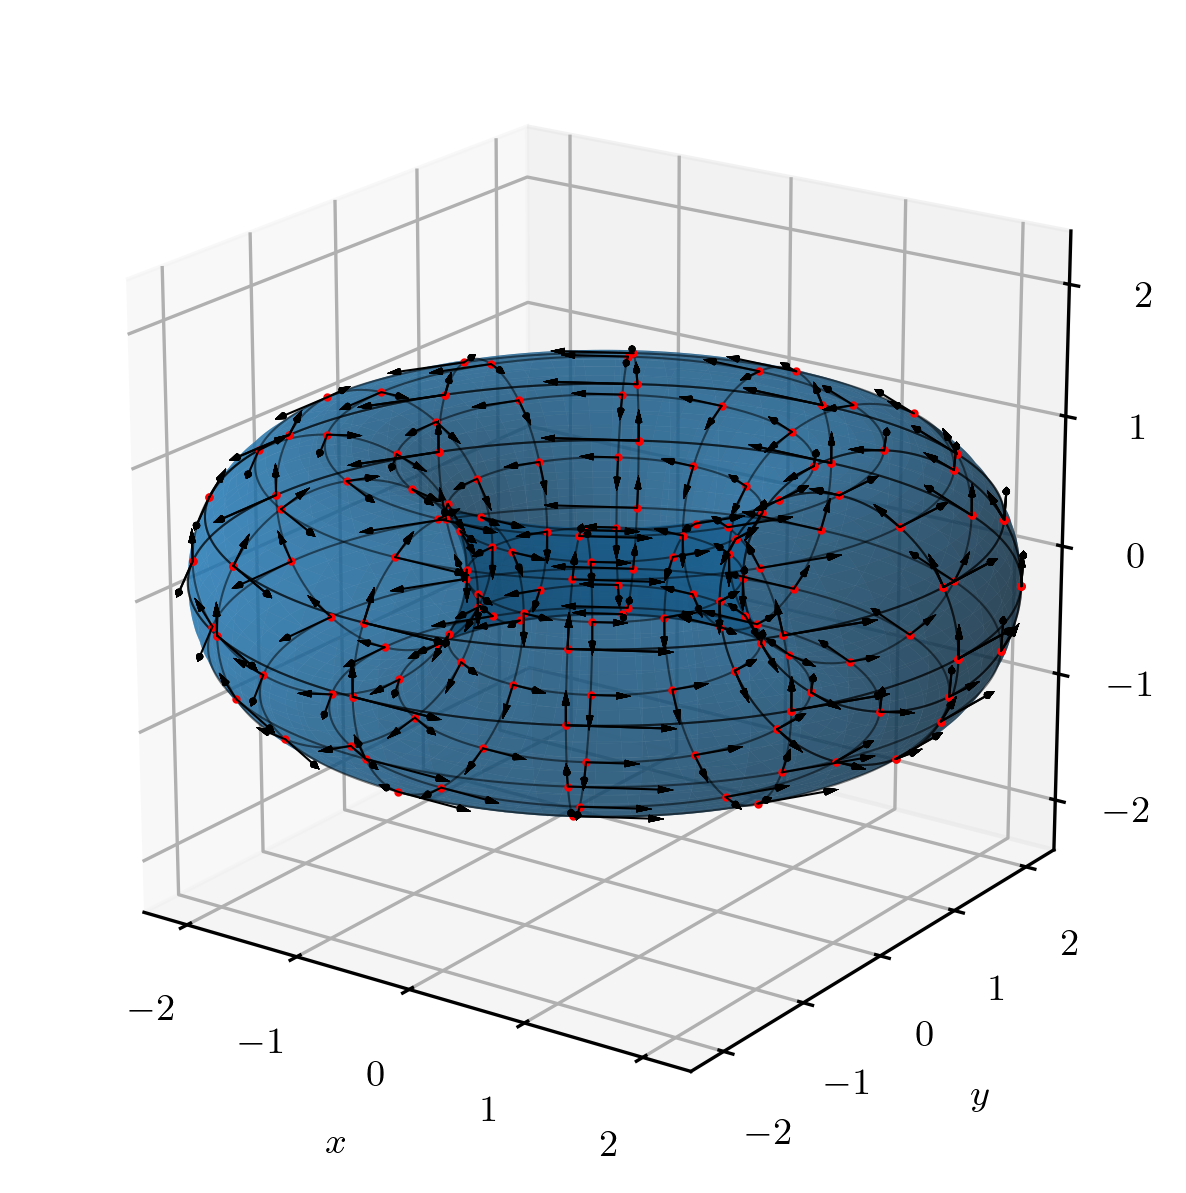

In [63]:
# parameters 
u = np.linspace(0,2*np.pi,1000) # u parameter 
v = np.linspace(0,2*np.pi,1000) # v parameter 

# minor radius 
r = 1

# major radius
R = 2
# R3 embedding functions x, y, z
def fx(u,v):
    return (R + r * np.cos(v)) * np.cos(u)

def fy(u,v):
    return (R + r * np.cos(v)) * np.sin(u)

def fz(u,v):
    return r * np.sin(v)

U, V = np.meshgrid(u,v)
R3 = np.array([
    fx(U,V),
    fy(U,V),
    fz(U,V)
])

fig = plt.figure(figsize=(4, 4), dpi=300)
ax = fig.add_subplot(111, projection='3d', computed_zorder = False)

# manifold embedding
ax.plot_surface(*R3, alpha=0.6,
    linewidth=0,
    edgecolor=None,
    antialiased=True,
    zorder = 1
                )

# coordinate curves
spaces = np.pi/6

# v coordinate curves
v_0 = np.arange(v.min(), v.max() + spaces, spaces)
for v0 in v_0:
    x0 = fx(u,v0)
    y0 = fy(u,v0)
    z0 = fz(u,v0) * np.ones_like(u)
    ax.plot(x0, y0, z0,'k-',lw=0.5, zorder = 2, alpha = 0.5)

# u coodinate curves
u_0 = np.arange(u.min(), u.max() + spaces, spaces)
for u0 in u_0:
    x0 = fx(u0,v)
    y0 = fy(u0,v)
    z0 = fz(u0,v)
    ax.plot(x0, y0, z0,'k-',lw=0.5, zorder = 2, alpha = 0.5)


# individual basis on a point p
# p = np.pi/6 * np.array([-1,1])
# rp = np.array([fx(*p), fy(*p), fz(*p)])
# ax.scatter(*rp, color = 'r', s = 3, zorder = 5)

# h = 1e-6 
# du_p = np.array([
#     (fx(p[0]+h,p[1]) - fx(p[0]-h,p[1]))/(2*h),
#     (fy(p[0]+h,p[1]) - fy(p[0]-h,p[1]))/(2*h),
#     (fz(p[0]+h,p[1]) - fz(p[0]-h,p[1]))/(2*h)
# ])

# dv_p = np.array([
#     (fx(p[0],p[1]+h) - fx(p[0],p[1]-h))/(2*h),
#     (fy(p[0],p[1]+h) - fy(p[0],p[1]-h))/(2*h),
#     (fz(p[0],p[1]+h) - fz(p[0],p[1]-h))/(2*h)
# ])
   
# ax.quiver_cone(*rp, *du_p, color="k", linewidth=0.8,
#                 headlength=0.25, headwidth=0.05, zorder=4)
# ax.quiver_cone(*rp, *dv_p, color="k", linewidth=0.8,
#                 headlength=0.25, headwidth=0.05, zorder=4)

U0, V0 = np.meshgrid(u_0, v_0)
for u0, v0 in zip(U0.ravel(), V0.ravel()):
    p = np.array([u0, v0])
    rp = np.array([fx(*p), fy(*p), fz(*p)])
    ax.scatter(*rp, color = 'r', s = 1, zorder = 5)

    h = 1e-6 
    du_p = np.array([
        (fx(p[0]+h,p[1]) - fx(p[0]-h,p[1]))/(2*h),
        (fy(p[0]+h,p[1]) - fy(p[0]-h,p[1]))/(2*h),
        (fz(p[0]+h,p[1]) - fz(p[0]-h,p[1]))/(2*h)
    ])

    dv_p = np.array([
        (fx(p[0],p[1]+h) - fx(p[0],p[1]-h))/(2*h),
        (fy(p[0],p[1]+h) - fy(p[0],p[1]-h))/(2*h),
        (fz(p[0],p[1]+h) - fz(p[0],p[1]-h))/(2*h)
    ])
    scale = 1/4

    dv_p *= scale 
    du_p *= scale
    ax.quiver_cone(*rp, *du_p, color="k", linewidth=0.5,
                    headlength=0.1, headwidth=0.025, zorder=4)
    ax.quiver_cone(*rp, *dv_p, color="k", linewidth=0.5,
                    headlength=0.1, headwidth=0.025, zorder=4)
    
lims = (-1.2 * R, 1.2 * R)
ax.set_xlim(*lims)
ax.set_ylim(*lims)
ax.set_zlim(*lims)
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')
ax.view_init(elev=20, azim=-55)
plt.tight_layout()
plt.show()


